# COMP 352 – Final Project: Footballer Market Evaluation  
**Goal:** Predict a footballer’s **market value next year** using **only historical information** (no future leakage).  

**Authors:** Zevin Attisha, Christian Vaikona, Santiago Guerrero, Santiago Pedetti   

**Dataset source:** https://www.kaggle.com/datasets/davidcariboo/player-scores  

---

## Table of Contents
1. Environment Setup  
2. Data Importing and Pre-processing  
3. Data Analysis and Visualization  
4. Data Analytics (Modeling)  
5. Summary / Conclusions  


## 1. Data Importing and Pre-processing (100 Points)
- Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
- Clean, wrangle, and handle missing data, duplicate data, etc.
- Encode any categorical variables
- Perform feature engineering on the dataset
- Transform data appropriately using techniques such as aggregation, normalization, and feature construction
- Reduce redundant data and perform need based discretization

We load two datasets:
- `player_valuations.csv`: multiple valuation records per player over time
- `players.csv`: one record per player with demographic and categorical info

We then clean data, engineer historical features, and build a **time-based target**: next year's market value.

## Environment Setup
This notebook uses common Python data science libraries (pandas, numpy, matplotlib, scikit-learn).

In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True)

In [48]:
PATH_PLAYER_VALUATIONS = "data/raw/player_valuations.csv"
PATH_PLAYERS = "data/raw/players.csv"
PATH_APPEARANCES = "data/raw/appearances.csv"
PATH_LINEUPS = "data/raw/game_lineups.csv"  

player_valuations_df = pd.read_csv(PATH_PLAYER_VALUATIONS)
players_df = pd.read_csv(PATH_PLAYERS)
appearances_df = pd.read_csv(PATH_APPEARANCES)
lineups_df = pd.read_csv(PATH_LINEUPS)    

print("player_valuations_df shape:", player_valuations_df.shape)
print("players_df shape:", players_df.shape)
print("appearances_df shape:", appearances_df.shape)
print("lineups_df shape:", lineups_df.shape) 

print("player_valuations_df:")
display(player_valuations_df.head())

print("players_df:")
display(players_df.head())

print("appearances_df:")
display(appearances_df.head())

print("lineups_df:")
display(lineups_df.head())


player_valuations_df shape: (496606, 5)
players_df shape: (32601, 23)
appearances_df shape: (1706806, 13)
lineups_df shape: (2191911, 10)
player_valuations_df:


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


players_df:


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09 00:00:00,Centre-Forward,Attack,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06 00:00:00,Goalkeeper,Goalkeeper,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30 00:00:00,Centre-Forward,Attack,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,1978-05-08 00:00:00,Centre-Back,Defender,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,1981-03-18 00:00:00,Goalkeeper,Goalkeeper,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


appearances_df:


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


lineups_df:


,game_lineups_id,date,game_id,player_id,club_id,player_name,type,position,number,team_captain
0,b2dbe01c3656b06c8e23e9de714e26bb,2013-07-27,2317258,1443,610,Christian Poulsen,substitutes,Defensive Midfield,5,0
1,b50a3ec6d52fd1490aab42042ac4f738,2013-07-27,2317258,5017,610,Niklas Moisander,starting_lineup,Centre-Back,4,0
2,7d890e6d0ff8af84b065839966a0ec81,2013-07-27,2317258,9602,1090,Maarten Martens,substitutes,Left Winger,11,0
3,8c355268678b9bbc7084221b1f0fde36,2013-07-27,2317258,12282,610,Daley Blind,starting_lineup,Left-Back,17,0
4,76193074d549e5fdce4cdcbba0d66247,2013-07-27,2317258,25427,1090,Roy Beerens,starting_lineup,Right Winger,23,0


In [49]:
# ===== Duplicate Check =====
print("=" * 60)
print("=== Duplicate Data Check ===")
print("=" * 60)

print("\nPlayer Valuations Dataset:")
print(f"Total rows: {len(player_valuations_df)}")
print(f"Duplicate rows: {player_valuations_df.duplicated().sum()}")
if player_valuations_df.duplicated().sum() > 0:
    print(f"Removing {player_valuations_df.duplicated().sum()} duplicate rows...")
    player_valuations_df = player_valuations_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(player_valuations_df)}")
else:
    print("No duplicate rows found.")

print("\nPlayers Dataset:")
print(f"Total rows: {len(players_df)}")
print(f"Duplicate rows: {players_df.duplicated().sum()}")
if players_df.duplicated().sum() > 0:
    print(f"Removing {players_df.duplicated().sum()} duplicate rows...")
    players_df = players_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(players_df)}")
else:
    print("No duplicate rows found.")

=== Duplicate Data Check ===

Player Valuations Dataset:
Total rows: 496606
Duplicate rows: 0
No duplicate rows found.

Players Dataset:
Total rows: 32601
Duplicate rows: 0
No duplicate rows found.


In [50]:

print("player_valuations_df dtypes:")
display(player_valuations_df.dtypes)

print("\nplayers_df dtypes:")
display(players_df.dtypes)

print("\nappearances_df dtypes:")
display(appearances_df.dtypes)

# Columns that display the most missing values in descending order

print("\nMissing values (top 10) - player_valuations_df:")
display(player_valuations_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values (top 10) - players_df:")
display(players_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values - appearances_df:")
display(appearances_df.isna().sum())
print("\nSample of appearances data:")
display(appearances_df.head(10))


player_valuations_df dtypes:


player_id                               int64
date                                   object
market_value_in_eur                     int64
current_club_id                         int64
player_club_domestic_competition_id    object
dtype: object


players_df dtypes:


player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name                       


appearances_df dtypes:


...

agent_name                     16019
contract_expiration_date       12091
country_of_birth                2799
foot                            2536
city_of_birth                   2455
height_in_cm                    2256
first_name                      2062
highest_market_value_in_eur     1523
market_value_in_eur             1523
country_of_citizenship           383
dtype: int64


Missing values - appearances_df:


appearance_id             0
game_id                   0
player_id                 0
player_club_id            0
player_current_club_id    0
date                      0
player_name               6
competition_id            0
yellow_cards              0
red_cards                 0
goals                     0
assists                   0
minutes_played            0
dtype: int64


Sample of appearances data:


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90
5,2234421_146889,2234421,146889,195,2778,2012-07-05,Peter Ankersen,ELQ,1,0,0,0,90
6,2235539_28716,2235539,28716,282,7185,2012-07-05,Adi Adilovic,ELQ,0,0,0,0,90
7,2235539_69445,2235539,69445,282,19771,2012-07-05,Ivan Sesar,ELQ,1,0,0,1,90
8,2235545_19409,2235545,19409,317,200,2012-07-05,Willem Janssen,ELQ,0,0,0,0,45
9,2235545_30003,2235545,30003,317,317,2012-07-05,Wout Brama,ELQ,0,0,0,0,90


In [51]:
# Clean appearances data
app = appearances_df.copy()

# Parse date to datetime
app['date'] = pd.to_datetime(app['date'], errors='coerce')
app = app.dropna(subset=['date'])

# Extract year from match date
app['year'] = app['date'].dt.year

# Fill missing performance stats with 0 (player appeared but didn't score/assist)
app['goals'] = app['goals'].fillna(0)
app['assists'] = app['assists'].fillna(0)
app['minutes_played'] = app['minutes_played'].fillna(0)
app['yellow_cards'] = app['yellow_cards'].fillna(0)
app['red_cards'] = app['red_cards'].fillna(0)

print("app shape after cleaning:", app.shape)
print("\nSample:")
display(app[['player_id', 'date', 'year', 'goals', 'assists', 'minutes_played']].head(10))

app shape after cleaning: (1706806, 14)

Sample:


,player_id,date,year,goals,assists,minutes_played
0,38004,2012-07-03,2012,2,0,90
1,79232,2012-07-05,2012,0,0,90
2,42792,2012-07-05,2012,0,0,45
3,73333,2012-07-05,2012,0,0,90
4,122011,2012-07-05,2012,0,1,90
5,146889,2012-07-05,2012,0,0,90
6,28716,2012-07-05,2012,0,0,90
7,69445,2012-07-05,2012,0,1,90
8,19409,2012-07-05,2012,0,0,45
9,30003,2012-07-05,2012,0,0,90


In [52]:
# ========== FIX: Aggregate performance CUMULATIVELY by date ==========
# For each player-date, we want cumulative stats UP TO that date in the season

# Sort by player and date
app = app.sort_values(['player_id', 'date']).reset_index(drop=True)

# Create a "season year" (football seasons span two calendar years)
# Let's use simple calendar year for now, but adjust if needed
app['year'] = app['date'].dt.year

# For each player-year-date, compute cumulative stats UP TO that date
app['cumulative_goals'] = app.groupby(['player_id', 'year'])['goals'].cumsum()
app['cumulative_assists'] = app.groupby(['player_id', 'year'])['assists'].cumsum()
app['cumulative_minutes'] = app.groupby(['player_id', 'year'])['minutes_played'].cumsum()
app['cumulative_yellows'] = app.groupby(['player_id', 'year'])['yellow_cards'].cumsum()
app['cumulative_reds'] = app.groupby(['player_id', 'year'])['red_cards'].cumsum()
app['cumulative_appearances'] = app.groupby(['player_id', 'year']).cumcount() + 1

# Keep only the most recent row per player per date (in case multiple games same day)
app_cumulative = app.groupby(['player_id', 'date']).tail(1).reset_index(drop=True)

# Select columns for merge
app_for_merge = app_cumulative[[
    'player_id', 'date',
    'cumulative_goals', 'cumulative_assists', 'cumulative_minutes',
    'cumulative_yellows', 'cumulative_reds', 'cumulative_appearances'
]].copy()

print("app_for_merge shape:", app_for_merge.shape)
print("\nSample:")
display(app_for_merge.head(20))
print("\nCumulative performance stats created successfully!")
print("Next step: Use merge_asof to join with valuation data")

app_for_merge shape: (1706792, 8)

Sample:


,player_id,date,cumulative_goals,cumulative_assists,cumulative_minutes,cumulative_yellows,cumulative_reds,cumulative_appearances
0,10,2012-08-23,1,0,83,1,0,1
1,10,2012-08-26,1,0,173,2,0,2
2,10,2012-09-02,3,0,262,3,0,3
3,10,2012-09-16,4,0,352,3,0,4
4,10,2012-09-20,4,0,442,3,0,5
5,10,2012-09-23,4,0,456,3,0,6
6,10,2012-09-26,4,0,546,3,0,7
7,10,2012-09-30,4,1,636,4,0,8
8,10,2012-10-07,6,1,708,4,0,9
9,10,2012-10-20,7,1,798,4,0,10



Cumulative performance stats created successfully!
Next step: Use merge_asof to join with valuation data


We keep only the columns needed for modeling and remove columns that are not useful or could cause leakage (e.g., current market value fields in `players.csv`).

In [53]:
pv = player_valuations_df.copy()

# Parse date
pv["date"] = pd.to_datetime(pv["date"], errors="coerce")
pv = pv.dropna(subset=["date"])

# Remove duplicates (same player_id & date)
pv = pv.drop_duplicates(subset=["player_id", "date"], keep="last")

# Keep essential columns
pv = pv[[
    "player_id",
    "date",
    "market_value_in_eur",
    "current_club_id",
    "player_club_domestic_competition_id"
]].copy()

# Rename for clarity
pv = pv.rename(columns={
    "market_value_in_eur": "market_value_in_eur_valuation",
    "current_club_id": "current_club_id_valuation",
    "player_club_domestic_competition_id": "domestic_competition_id_valuation"
})

print("pv shape:", pv.shape)
pv.head()


pv shape: (496606, 5)


,player_id,date,market_value_in_eur_valuation,current_club_id_valuation,domestic_competition_id_valuation
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [54]:
# Clean players (p)

p = players_df.copy()

# Parse birth date
p["date_of_birth"] = pd.to_datetime(p["date_of_birth"], errors="coerce")

# Keep only safe player-level features (no leakage)
keep_player_cols = [
    "player_id",
    "date_of_birth",
    "position",
    "sub_position",
    "foot",
    "height_in_cm"
]
p = p[keep_player_cols].copy()

# Handle missing categoricals
p["position"] = p["position"].fillna("Missing")
p["sub_position"] = p["sub_position"].fillna("Missing")
p["foot"] = p["foot"].fillna("Missing")

# Numeric height + impute
p["height_in_cm"] = pd.to_numeric(p["height_in_cm"], errors="coerce")
p["height_in_cm"] = p["height_in_cm"].fillna(p["height_in_cm"].median())

# Birth date required for age feature
p = p.dropna(subset=["date_of_birth"])

print("p shape:", p.shape)
p.head()


p shape: (32554, 6)


,player_id,date_of_birth,position,sub_position,foot,height_in_cm
0,10,1978-06-09,Attack,Centre-Forward,right,184.0
1,26,1980-08-06,Goalkeeper,Goalkeeper,left,190.0
2,65,1981-01-30,Attack,Centre-Forward,Missing,183.0
3,77,1978-05-08,Defender,Centre-Back,Missing,183.0
4,80,1981-03-18,Goalkeeper,Goalkeeper,right,194.0


We merge valuation records with player info using `player_id`. Each valuation row becomes a modeling row with player features attached.

In [75]:
# ========== Merge player valuations with player info ==========
merged_df = pv.merge(p, on="player_id", how="left")

# Drop valuation rows missing player info
merged_df = merged_df.dropna(subset=["date_of_birth"])

print("merged_df shape:", merged_df.shape)
merged_df.head()


# ========== Yearly snapshots (1 row per player per year) ==========

# Ensure datetime for valuation date
merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.dropna(subset=["date"])

# Create a year column
merged_df["year"] = merged_df["date"].dt.year

# Keep only the last valuation within each year per player
merged_df = (
    merged_df.sort_values(["player_id", "date"])
             .groupby(["player_id", "year"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)

print("merged_df shape after yearly snapshot:", merged_df.shape)
merged_df[["player_id", "date", "year", "market_value_in_eur_valuation"]].head()


# ========== FIX: Manual merge_asof by player (NO LEAKAGE) ==========
print("\n" + "="*80)
print("MERGING PERFORMANCE STATISTICS WITH TEMPORAL INTEGRITY")
print("Using manual player-by-player merge (more reliable)")
print("="*80)

# Ensure data types
merged_df['player_id'] = merged_df['player_id'].astype(int)
app_for_merge['player_id'] = app_for_merge['player_id'].astype(int)
merged_df['date'] = pd.to_datetime(merged_df['date'])
app_for_merge['date'] = pd.to_datetime(app_for_merge['date'])

# Sort data
merged_df = merged_df.sort_values(['player_id', 'date']).reset_index(drop=True)
app_for_merge = app_for_merge.sort_values(['player_id', 'date']).reset_index(drop=True)

print(f"Starting merge for {merged_df['player_id'].nunique()} unique players...")
print(f"This may take 1-2 minutes...\n")

# Manual merge by player
result_list = []
unique_players = merged_df['player_id'].unique()

import time
start_time = time.time()

for i, pid in enumerate(unique_players):
    # Progress indicator every 1000 players
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i+1}/{len(unique_players)} players ({elapsed:.1f}s elapsed)...")
    
    # Get data for this player
    player_val = merged_df[merged_df['player_id'] == pid].copy()
    player_app = app_for_merge[app_for_merge['player_id'] == pid].copy()
    
    # Merge with appearances data if available
    if len(player_app) > 0:
        player_merged = pd.merge_asof(
            player_val.sort_values('date'),
            player_app.sort_values('date'),
            on='date',
            direction='backward',
            tolerance=pd.Timedelta(days=365),
            allow_exact_matches=True
        )
    else:
        # No appearance data for this player - keep valuation data with NaN performance
        player_merged = player_val
    
    result_list.append(player_merged)

# Combine all players
merged_df = pd.concat(result_list, ignore_index=True)

elapsed_total = time.time() - start_time
print(f"\n✅ Merge complete in {elapsed_total:.1f} seconds!")
print(f"Final merged_df shape: {merged_df.shape}")
print(f"Rows with performance data: {merged_df['cumulative_goals'].notna().sum()}")
print(f"Rows without performance data: {merged_df['cumulative_goals'].isna().sum()}")

# Rename cumulative columns
merged_df = merged_df.rename(columns={
    'cumulative_goals': 'total_goals',
    'cumulative_assists': 'total_assists',
    'cumulative_minutes': 'total_minutes',
    'cumulative_yellows': 'total_yellow_cards',
    'cumulative_reds': 'total_red_cards',
    'cumulative_appearances': 'num_appearances'
})

# Fill NaNs (players with no appearances before valuation date)
perf_cols = ['total_goals', 'total_assists', 'total_minutes', 'num_appearances',
             'total_yellow_cards', 'total_red_cards']
for col in perf_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0)

# Calculate per-90 stats
print("\nCalculating per-90 minute statistics...")
merged_df['goals_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    (merged_df['total_goals'] / merged_df['total_minutes']) * 90,
    0
)
merged_df['assists_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    (merged_df['total_assists'] / merged_df['total_minutes']) * 90,
    0
)
merged_df['goal_contributions_per_90'] = merged_df['goals_per_90'] + merged_df['assists_per_90']
merged_df['games_started_estimate'] = merged_df['total_minutes'] / 90
merged_df['cards_per_90'] = np.where(
    merged_df['total_minutes'] > 0,
    ((merged_df['total_yellow_cards'] + merged_df['total_red_cards'] * 2) / merged_df['total_minutes']) * 90,
    0
)

print(f"\n✅ Performance statistics merged with NO TEMPORAL LEAKAGE")
print(f"Final shape: {merged_df.shape}")
print("\nSample with performance features:")
display(merged_df[['player_id', 'date', 'year', 'market_value_in_eur_valuation', 
                    'total_goals', 'total_assists', 'total_minutes', 'goals_per_90']].head(10))

print(f"\n✅ Performance statistics merged with NO TEMPORAL LEAKAGE")
print(f"Final shape: {merged_df.shape}")
print("\nSample with performance features:")
display(merged_df[['player_id', 'date', 'year', 'market_value_in_eur_valuation', 
                    'total_goals', 'total_assists', 'total_minutes', 'goals_per_90']].head(10))

# Safe verification - check if ANY players have performance data
players_with_perf = merged_df[merged_df['total_goals'] > 0]
if len(players_with_perf) > 0:
    print(f"\n🔍 Verification - found {len(players_with_perf)} observations with goals > 0:")
    sample_player_id = players_with_perf['player_id'].iloc[0]
    sample_player = merged_df[merged_df['player_id'] == sample_player_id].head(5)
    display(sample_player[['player_id', 'date', 'year', 'total_goals', 'total_assists', 'total_minutes']])
else:
    print(f"\n⚠️ No players have goals > 0 in current dataset")
    print(f"This may indicate:")
    print(f"  1. Valuations are from before appearance data starts (2012)")
    print(f"  2. Tolerance window (365 days) may need adjustment")
    print(f"  3. Player IDs may not match between datasets")
    
    # Show date ranges
    print(f"\nDate ranges:")
    print(f"  Valuations: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(f"  Appearances: {app_for_merge['date'].min()} to {app_for_merge['date'].max()}")

merged_df shape: (496045, 10)
merged_df shape after yearly snapshot: (251792, 11)

MERGING PERFORMANCE STATISTICS WITH TEMPORAL INTEGRITY
Using manual player-by-player merge (more reliable)
Starting merge for 31046 unique players...
This may take 1-2 minutes...

Processed 1000/31046 players (1.1s elapsed)...
Processed 2000/31046 players (2.2s elapsed)...
Processed 3000/31046 players (3.4s elapsed)...
Processed 4000/31046 players (5.0s elapsed)...
Processed 5000/31046 players (6.1s elapsed)...
Processed 6000/31046 players (7.4s elapsed)...
Processed 7000/31046 players (8.6s elapsed)...
Processed 8000/31046 players (9.7s elapsed)...
Processed 9000/31046 players (10.9s elapsed)...
Processed 10000/31046 players (12.1s elapsed)...
Processed 11000/31046 players (13.2s elapsed)...
Processed 12000/31046 players (14.2s elapsed)...
Processed 13000/31046 players (15.5s elapsed)...
Processed 14000/31046 players (16.7s elapsed)...
Processed 15000/31046 players (17.8s elapsed)...
Processed 16000/310

,player_id,date,year,market_value_in_eur_valuation,total_goals,total_assists,total_minutes,goals_per_90
0,NaN,2004-10-04,2004,7000000,0.0,0.0,0.0,0.000000
1,NaN,2005-09-30,2005,15000000,0.0,0.0,0.0,0.000000
2,NaN,2006-07-15,2006,30000000,0.0,0.0,0.0,0.000000
3,NaN,2007-06-21,2007,23000000,0.0,0.0,0.0,0.000000
4,NaN,2008-06-04,2008,20000000,0.0,0.0,0.0,0.000000
5,NaN,2009-08-30,2009,12000000,0.0,0.0,0.0,0.000000
6,NaN,2010-05-08,2010,7500000,0.0,0.0,0.0,0.000000
7,NaN,2011-06-29,2011,5000000,0.0,0.0,0.0,0.000000
8,NaN,2012-07-03,2012,6000000,0.0,0.0,0.0,0.000000
9,NaN,2013-06-19,2013,2000000,5.0,2.0,1102.0,0.408348



✅ Performance statistics merged with NO TEMPORAL LEAKAGE
Final shape: (251792, 24)

Sample with performance features:


,player_id,date,year,market_value_in_eur_valuation,total_goals,total_assists,total_minutes,goals_per_90
0,NaN,2004-10-04,2004,7000000,0.0,0.0,0.0,0.000000
1,NaN,2005-09-30,2005,15000000,0.0,0.0,0.0,0.000000
2,NaN,2006-07-15,2006,30000000,0.0,0.0,0.0,0.000000
3,NaN,2007-06-21,2007,23000000,0.0,0.0,0.0,0.000000
4,NaN,2008-06-04,2008,20000000,0.0,0.0,0.0,0.000000
5,NaN,2009-08-30,2009,12000000,0.0,0.0,0.0,0.000000
6,NaN,2010-05-08,2010,7500000,0.0,0.0,0.0,0.000000
7,NaN,2011-06-29,2011,5000000,0.0,0.0,0.0,0.000000
8,NaN,2012-07-03,2012,6000000,0.0,0.0,0.0,0.000000
9,NaN,2013-06-19,2013,2000000,5.0,2.0,1102.0,0.408348



🔍 Verification - found 38877 observations with goals > 0:


,player_id,date,year,total_goals,total_assists,total_minutes


In [77]:
print("="*80)
print("CHECKING DATA BEFORE/AFTER LINEUPS MERGE")
print("="*80)

# This should show your current state
print(f"Current merged_df shape: {merged_df.shape}")
print(f"Players with goals > 0: {(merged_df['total_goals'] > 0).sum()}")
print(f"Players with minutes > 0: {(merged_df['total_minutes'] > 0).sum()}")

# Check if you accidentally filtered your data
print(f"\nDate range in current data:")
print(f"  Min: {merged_df['date'].min()}")
print(f"  Max: {merged_df['date'].max()}")
print(f"  Unique years: {sorted(merged_df['year'].unique())}")

CHECKING DATA BEFORE/AFTER LINEUPS MERGE
Current merged_df shape: (251792, 24)
Players with goals > 0: 38877
Players with minutes > 0: 93193

Date range in current data:
  Min: 2000-01-20 00:00:00
  Max: 2025-04-06 00:00:00
  Unique years: [np.int32(2000), np.int32(2001), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


We compute age at valuation date and create historical features (lags, trends, rolling mean). We also build the target: next year's market value.

In [78]:
# =========================
# Lineups feature engineering (NO TEMPORAL LEAKAGE)
# =========================

print("\n" + "="*80)
print("PROCESSING LINEUP DATA WITH TEMPORAL INTEGRITY")
print("="*80)

# Ensure datetime and year
lineups_df["date"] = pd.to_datetime(lineups_df["date"], errors="coerce")
lineups_df = lineups_df.dropna(subset=["date"])
lineups_df["year"] = lineups_df["date"].dt.year

# Identify starts from 'type'
lineups_df["is_start"] = (
    lineups_df["type"]
    .astype(str)
    .str.lower()
    .str.contains("start", na=False)
)

# Ensure captain flag is numeric
lineups_df["team_captain"] = lineups_df["team_captain"].fillna(0).astype(int)

# Sort by player and date
lineups_df = lineups_df.sort_values(['player_id', 'date']).reset_index(drop=True)

# Create cumulative counts by player-year
lineups_df['cumulative_matches'] = lineups_df.groupby(['player_id', 'year']).cumcount() + 1
lineups_df['cumulative_starts'] = lineups_df.groupby(['player_id', 'year'])['is_start'].cumsum()
lineups_df['cumulative_captain'] = lineups_df.groupby(['player_id', 'year'])['team_captain'].cumsum()

# Keep most recent row per player-date (in case of multiple games same day)
lineups_cumulative = lineups_df.groupby(['player_id', 'date']).tail(1).reset_index(drop=True)

# Select columns for merge
lineups_for_merge = lineups_cumulative[[
    'player_id', 'date',
    'cumulative_matches', 'cumulative_starts', 'cumulative_captain'
]].copy()

print(f"Prepared lineup data: {lineups_for_merge.shape}")
print("Starting player-by-player merge...")

# Drop old lineup columns if they exist (from previous run)
lineup_cols_to_drop = ['lineup_matches', 'starts', 'captain_matches', 'start_ratio']
for col in lineup_cols_to_drop:
    if col in merged_df.columns:
        merged_df = merged_df.drop(columns=[col])
        print(f"Dropped existing column: {col}")

# Manual merge by player (same approach as appearances)
import time
start_time = time.time()

result_list = []
unique_players = merged_df['player_id'].unique()

for i, pid in enumerate(unique_players):
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i+1}/{len(unique_players)} players ({elapsed:.1f}s elapsed)...")
    
    player_val = merged_df[merged_df['player_id'] == pid].copy()
    player_lineup = lineups_for_merge[lineups_for_merge['player_id'] == pid].copy()
    
    if len(player_lineup) > 0:
        # Drop player_id from lineup data since it's already in player_val
        player_lineup_merge = player_lineup[['date', 'cumulative_matches', 'cumulative_starts', 'cumulative_captain']].copy()
        
        player_merged = pd.merge_asof(
            player_val.sort_values('date'),
            player_lineup_merge.sort_values('date'),
            on='date',
            direction='backward',
            tolerance=pd.Timedelta(days=365),
            allow_exact_matches=True
        )
    else:
        player_merged = player_val
    
    result_list.append(player_merged)

merged_df = pd.concat(result_list, ignore_index=True)

elapsed_total = time.time() - start_time
print(f"\n✅ Lineup merge complete in {elapsed_total:.1f} seconds!")

# Check what columns we have
print(f"\nColumns after merge: {merged_df.columns.tolist()}")

# Rename cumulative columns if they exist
rename_map = {
    'cumulative_matches': 'lineup_matches',
    'cumulative_starts': 'starts',
    'cumulative_captain': 'captain_matches'
}
cols_to_rename = {k: v for k, v in rename_map.items() if k in merged_df.columns}
if cols_to_rename:
    merged_df = merged_df.rename(columns=cols_to_rename)
    print(f"Renamed columns: {cols_to_rename}")

# Fill NaNs first
for c in ["lineup_matches", "starts", "captain_matches"]:
    if c in merged_df.columns:
        merged_df[c] = merged_df[c].fillna(0)

# Calculate start ratio AFTER filling NaNs
if 'lineup_matches' in merged_df.columns and 'starts' in merged_df.columns:
    merged_df['start_ratio'] = np.where(
        merged_df['lineup_matches'] > 0,
        merged_df['starts'] / merged_df['lineup_matches'],
        0
    )
    merged_df['start_ratio'] = merged_df['start_ratio'].fillna(0)

print(f"\nmerged_df shape after adding lineup features (NO LEAKAGE): {merged_df.shape}")
print(f"Rows with lineup data: {(merged_df.get('lineup_matches', pd.Series([0])) > 0).sum()}")
print(f"Rows without lineup data: {(merged_df.get('lineup_matches', pd.Series([0])) == 0).sum()}")

print("\nSample with lineup features:")
sample_cols = ["player_id", "date", "year"]
if 'starts' in merged_df.columns:
    sample_cols.extend(["starts", "lineup_matches", "start_ratio", "captain_matches"])
display(merged_df[sample_cols].head(10))

print("\n✅ All temporal leakage fixes complete!")
print("Both appearances and lineup data now use only information from BEFORE valuation date")


PROCESSING LINEUP DATA WITH TEMPORAL INTEGRITY
Prepared lineup data: (2191895, 5)
Starting player-by-player merge...
Processed 1000/5743 players (2.6s elapsed)...
Processed 2000/5743 players (4.8s elapsed)...
Processed 3000/5743 players (6.9s elapsed)...
Processed 4000/5743 players (9.1s elapsed)...
Processed 5000/5743 players (11.3s elapsed)...

✅ Lineup merge complete in 13.2 seconds!

Columns after merge: ['player_id_x', 'date', 'market_value_in_eur_valuation', 'current_club_id_valuation', 'domestic_competition_id_valuation', 'date_of_birth', 'position', 'sub_position', 'foot', 'height_in_cm', 'year', 'player_id_y', 'total_goals', 'total_assists', 'total_minutes', 'total_yellow_cards', 'total_red_cards', 'num_appearances', 'player_id', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'games_started_estimate', 'cards_per_90', 'cumulative_matches', 'cumulative_starts', 'cumulative_captain']
Renamed columns: {'cumulative_matches': 'lineup_matches', 'cumulative_starts': '

,player_id,date,year,starts,lineup_matches,start_ratio,captain_matches
0,162.0,2004-10-04,2004,0.0,0.0,0.0,0.0
1,162.0,2005-06-10,2005,0.0,0.0,0.0,0.0
2,162.0,2006-06-27,2006,0.0,0.0,0.0,0.0
3,162.0,2007-06-21,2007,0.0,0.0,0.0,0.0
4,162.0,2008-01-01,2008,0.0,0.0,0.0,0.0
5,162.0,2009-06-10,2009,0.0,0.0,0.0,0.0
6,162.0,2010-08-26,2010,0.0,0.0,0.0,0.0
7,162.0,2011-10-18,2011,0.0,0.0,0.0,0.0
8,162.0,2012-06-29,2012,0.0,0.0,0.0,0.0
9,162.0,2013-01-13,2013,0.0,0.0,0.0,0.0



✅ All temporal leakage fixes complete!
Both appearances and lineup data now use only information from BEFORE valuation date


In [80]:

# Feature Engineering (time series per player, yearly)
# At this point, merged_df has ONE row per player per year (yearly snapshot).
# We now compute age, create a next-year target, and build historical lag features.

merged_df = merged_df.sort_values(["player_id", "year"]).reset_index(drop=True)

# Age at time of valuation
merged_df["age_at_valuation"] = ((merged_df["date"] - merged_df["date_of_birth"]).dt.days / 365.25)

# Target: next year's value (t+1 year)
merged_df["market_value_next_year"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(-1)
)

# Historical lags (past only)
merged_df["market_value_lag_1"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(1)
)
merged_df["market_value_lag_2"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(2)
)

# Dynamics
merged_df["market_value_trend"] = merged_df["market_value_lag_1"] - merged_df["market_value_lag_2"]

# Rolling mean (past only) - use shift(1) then rolling window
merged_df["market_value_mean_3"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Create performance lag features (historical performance)
merged_df['goals_lag_1'] = merged_df.groupby('player_id')['total_goals'].shift(1)
merged_df['assists_lag_1'] = merged_df.groupby('player_id')['total_assists'].shift(1)
merged_df['minutes_lag_1'] = merged_df.groupby('player_id')['total_minutes'].shift(1)
merged_df['goals_per_90_lag_1'] = merged_df.groupby('player_id')['goals_per_90'].shift(1)

# Performance trends (year-over-year changes)
merged_df['goals_trend'] = merged_df['total_goals'] - merged_df['goals_lag_1']
merged_df['minutes_trend'] = merged_df['total_minutes'] - merged_df['minutes_lag_1']

# Fill NaNs in performance features
perf_lag_cols = ['goals_lag_1', 'assists_lag_1', 'minutes_lag_1', 
                 'goals_per_90_lag_1', 'goals_trend', 'minutes_trend']
for col in perf_lag_cols:
    merged_df[col] = merged_df[col].fillna(0)

print("Performance lag features created")

# Drop rows without enough history or target
# Drop rows without ESSENTIAL data only (more lenient)
print(f"\nBefore dropping rows: {merged_df.shape}")

# Only require target and at least 1 lag (not 2 or 3)
merged_df = merged_df.dropna(subset=[
    "market_value_next_year",
    "market_value_lag_1",  # At least 1 year of history
    "age_at_valuation"
])

print(f"After dropping rows without target/lag1/age: {merged_df.shape}")

# Fill remaining NaN features with 0 (lag_2, mean_3, etc.)
lag_fill_cols = ["market_value_lag_2", "market_value_mean_3", "market_value_trend"]
for col in lag_fill_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0)
        
print(f"Filled NaN lag features with 0")
print(f"Final shape after FE: {merged_df.shape}")

print("merged_df shape after FE:", merged_df.shape)
merged_df[["player_id","year","market_value_in_eur_valuation","market_value_next_year","market_value_lag_1","market_value_lag_2"]].head(10)

Performance lag features created

Before dropping rows: (9344, 40)
After dropping rows without target/lag1/age: (5132, 40)
Filled NaN lag features with 0
Final shape after FE: (5132, 40)
merged_df shape after FE: (5132, 40)


,player_id,year,market_value_in_eur_valuation,market_value_next_year,market_value_lag_1,market_value_lag_2
1,162.0,2008,1000000,800000.0,600000.0,0.0
2,162.0,2009,800000,500000.0,1000000.0,600000.0
3,162.0,2010,500000,300000.0,800000.0,1000000.0
4,162.0,2011,300000,200000.0,500000.0,800000.0
7,643.0,2010,500000,300000.0,600000.0,0.0
8,643.0,2011,300000,200000.0,500000.0,600000.0
11,1122.0,2011,300000,200000.0,300000.0,0.0
14,1257.0,2008,150000,550000.0,100000.0,0.0
15,1257.0,2009,550000,600000.0,150000.0,100000.0
16,1257.0,2010,600000,600000.0,550000.0,150000.0


In [58]:
# Feature Discretization
print("=" * 60)
print("=== Feature Discretization ===")
print("=" * 60)

# Age groups based on football career stages
merged_df['age_group'] = pd.cut(
    merged_df['age_at_valuation'], 
    bins=[0, 23, 28, 33, 50], 
    labels=['Young (≤23)', 'Prime (24-28)', 'Experienced (29-33)', 'Veteran (34+)']
)

# Valuation tiers
merged_df['value_tier'] = pd.cut(
    merged_df['market_value_in_eur_valuation'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

# Target value tiers (for next year prediction)
merged_df['target_value_tier'] = pd.cut(
    merged_df['market_value_next_year'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

print("\nSample of discretized features:")
print(merged_df[['player_id', 'age_at_valuation', 'age_group', 
                  'market_value_in_eur_valuation', 'value_tier']].head(10))

print(f"\nAge Group Distribution:")
print(merged_df['age_group'].value_counts().sort_index())

print(f"\nCurrent Value Tier Distribution:")
print(merged_df['value_tier'].value_counts().sort_index())

print(f"\nTarget Value Tier Distribution:")
print(merged_df['target_value_tier'].value_counts().sort_index())

=== Feature Discretization ===

Sample of discretized features:
    player_id  age_at_valuation            age_group  \
3       162.0         31.019849  Experienced (29-33)   
4       162.0         31.550992  Experienced (29-33)   
5       162.0         32.991102  Experienced (29-33)   
6       162.0         34.201232        Veteran (34+)   
7       162.0         35.345654        Veteran (34+)   
8       162.0         36.043806        Veteran (34+)   
13      643.0         28.358658  Experienced (29-33)   
14      643.0         29.724846  Experienced (29-33)   
15      643.0         30.677618  Experienced (29-33)   
16      643.0         31.679671  Experienced (29-33)   

    market_value_in_eur_valuation value_tier  
3                          600000  Low (<1M)  
4                         1000000  Low (<1M)  
5                          800000  Low (<1M)  
6                          500000  Low (<1M)  
7                          300000  Low (<1M)  
8                          200000  Lo

We one-hot encode categorical columns used by the model.

In [59]:
# One-hot encoding

categorical_cols = [
    "position",
    "sub_position",
    "foot",
    "domestic_competition_id_valuation"
]

merged_encoded = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)

print("encoded shape:", merged_encoded.shape)


encoded shape: (9344, 72)


We build the feature matrix `X` and target `y`. We explicitly remove columns that would leak information (current valuation) and identifiers.

In [60]:
# Build X/y (no leakage)

y = merged_encoded["market_value_next_year"]

drop_cols = [
    "market_value_next_year",
    "market_value_in_eur_valuation",
    "player_id",
    "date",
    "date_of_birth",
    "year"
]
X = merged_encoded.drop(columns=[c for c in drop_cols if c in merged_encoded.columns])

# Ensure numeric + dummy (bool) columns are kept
X = X.select_dtypes(include=[np.number, "bool"]).copy()

# Convert bool dummies to 0/1 ints for sklearn
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Clean inf/NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", X.isna().any().any())

X shape: (9344, 63)
y shape: (9344,)
Any NaNs in X? True


## 2. Data Analysis and Visualization
We explore distributions, centrality measures, and relationships between features and the target.

In [61]:
# Summary Statistics
print("=" * 60)
print("=== Measures of Centrality and Distribution ===")
print("=" * 60)

print("\n MODEL VARIABLES:")
print("Dependent Variable (Target): market_value_next_year")
print("Independent Variables: age_at_valuation, height_in_cm, position features,")
print("                       market_value_lag_1, market_value_lag_2, market_value_trend,")
print("                       market_value_mean_3, performance statistics (goals, assists,")
print("                       minutes_played, goals_per_90), and other historical features\n")

# Key numerical variables for analysis
key_vars = ['market_value_in_eur_valuation', 'market_value_next_year', 
            'age_at_valuation', 'height_in_cm', 
            'market_value_lag_1', 'market_value_trend',
            'total_goals', 'total_assists', 'total_minutes',
            'goals_per_90', 'assists_per_90', 'num_appearances']  

print("=" * 60)
print("Summary Statistics for Key Variables")
print("=" * 60)
summary_stats = merged_df[key_vars].describe()
display(summary_stats)

print("\n" + "=" * 60)
print("Additional Measures of Centrality")
print("=" * 60)
for var in key_vars:
    print(f"\n{var}:")
    print(f"  Mean:     €{merged_df[var].mean():,.2f}" if 'value' in var or 'market' in var 
          else f"  Mean:     {merged_df[var].mean():.2f}")
    print(f"  Median:   €{merged_df[var].median():,.2f}" if 'value' in var or 'market' in var 
          else f"  Median:   {merged_df[var].median():.2f}")
    mode_val = merged_df[var].mode()
    print(f"  Mode:     {mode_val[0]:.2f}" if len(mode_val) > 0 else "  Mode:     N/A")
    print(f"  Std Dev:  €{merged_df[var].std():,.2f}" if 'value' in var or 'market' in var 
          else f"  Std Dev:  {merged_df[var].std():.2f}")
    print(f"  Skewness: {merged_df[var].skew():.2f}")
    print(f"  Kurtosis: {merged_df[var].kurtosis():.2f}") # Peakness of probability distribution

print("\n" + "=" * 60)

=== Measures of Centrality and Distribution ===

 MODEL VARIABLES:
Dependent Variable (Target): market_value_next_year
Independent Variables: age_at_valuation, height_in_cm, position features,
                       market_value_lag_1, market_value_lag_2, market_value_trend,
                       market_value_mean_3, performance statistics (goals, assists,
                       minutes_played, goals_per_90), and other historical features

Summary Statistics for Key Variables


,market_value_in_eur_valuation,market_value_next_year,age_at_valuation,height_in_cm,market_value_lag_1,market_value_trend,total_goals,total_assists,total_minutes,goals_per_90,assists_per_90,num_appearances
count,9.344000e+03,9.344000e+03,9344.000000,9344.000000,9.344000e+03,9.344000e+03,9344.0,9344.0,9344.0,9344.0,9344.0,9344.0
mean,3.094440e+05,2.904934e+05,25.310019,183.384525,3.200813e+05,5.665668e+03,0.0,0.0,0.0,0.0,0.0,0.0
std,5.649575e+05,5.236895e+05,3.534339,6.286136,5.899429e+05,3.187803e+05,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000e+04,1.000000e+04,17.683778,160.000000,1.000000e+04,-8.500000e+06,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.000000e+05,1.000000e+05,22.657769,179.000000,1.000000e+05,-5.000000e+04,0.0,0.0,0.0,0.0,0.0,0.0
50%,2.000000e+05,1.750000e+05,24.676249,183.000000,2.000000e+05,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
75%,3.000000e+05,3.000000e+05,27.381930,188.000000,3.000000e+05,5.000000e+04,0.0,0.0,0.0,0.0,0.0,0.0
max,1.500000e+07,1.500000e+07,42.548939,204.000000,1.500000e+07,7.500000e+06,0.0,0.0,0.0,0.0,0.0,0.0



Additional Measures of Centrality

market_value_in_eur_valuation:
  Mean:     €309,444.03
  Median:   €200,000.00
  Mode:     100000.00
  Std Dev:  €564,957.50
  Skewness: 10.26
  Kurtosis: 172.43

market_value_next_year:
  Mean:     €290,493.36
  Median:   €175,000.00
  Mode:     100000.00
  Std Dev:  €523,689.51
  Skewness: 10.47
  Kurtosis: 190.60

age_at_valuation:
  Mean:     25.31
  Median:   24.68
  Mode:     22.76
  Std Dev:  3.53
  Skewness: 0.87
  Kurtosis: 0.70

height_in_cm:
  Mean:     183.38
  Median:   183.00
  Mode:     183.00
  Std Dev:  6.29
  Skewness: -0.11
  Kurtosis: -0.05

market_value_lag_1:
  Mean:     €320,081.34
  Median:   €200,000.00
  Mode:     100000.00
  Std Dev:  €589,942.89
  Skewness: 9.83
  Kurtosis: 156.97

market_value_trend:
  Mean:     €5,665.67
  Median:   €0.00
  Mode:     0.00
  Std Dev:  €318,780.31
  Skewness: 0.61
  Kurtosis: 158.46

total_goals:
  Mean:     0.00
  Median:   0.00
  Mode:     0.00
  Std Dev:  0.00
  Skewness: 0.00
  Kurtosi

In [62]:
merged_df[["starts", "lineup_matches", "start_ratio", "captain_matches"]].describe()


,starts,lineup_matches,start_ratio,captain_matches
count,9344.000000,9344.000000,9344.000000,9344.000000
mean,0.326092,0.985980,0.152898,0.014341
std,0.923570,2.484096,0.342019,0.174372
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,0.000000
max,14.000000,42.000000,1.000000,5.000000


KeyError: 'start_ratio'

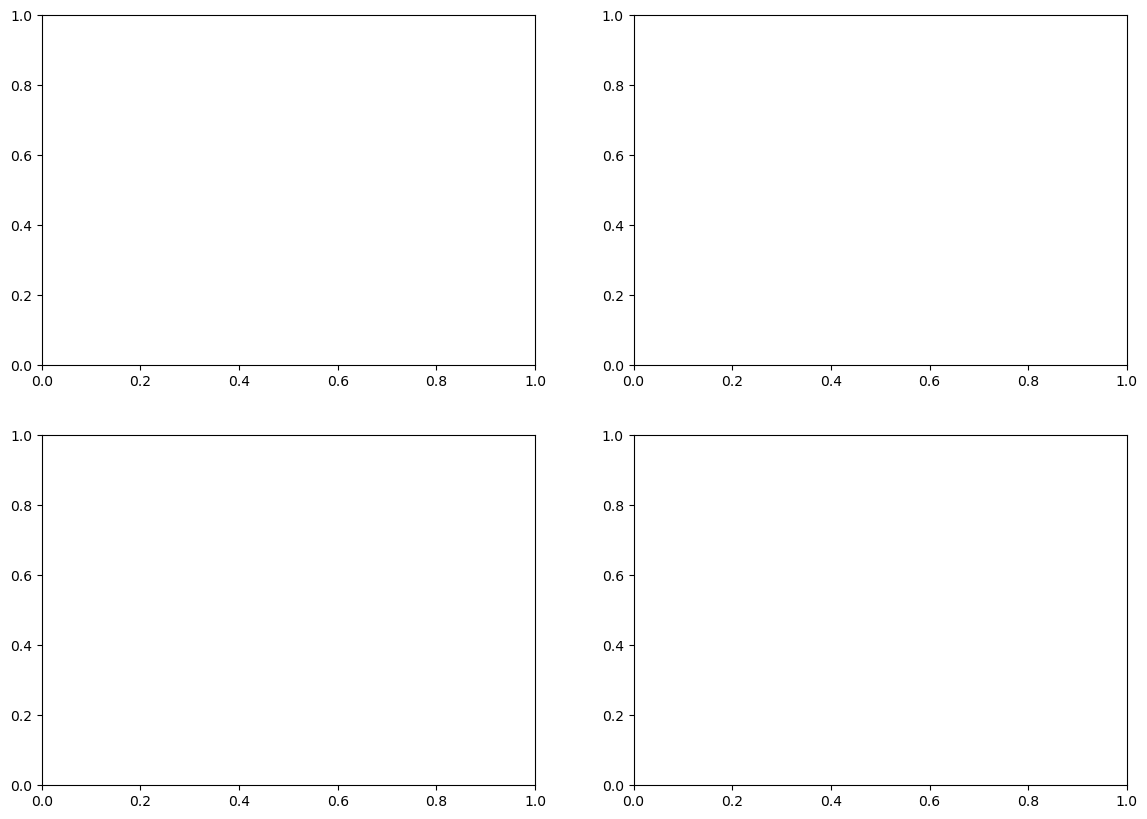

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(["Attack", "Midfield", "Defender", "Goalkeeper"]):
    pos_data = merged_df[merged_df["position"] == pos]

    axes[idx].scatter(
        pos_data["start_ratio"],
        pos_data["market_value_in_eur_valuation"],
        alpha=0.4, s=15
    )
    axes[idx].set_title(f"{pos}: Start Ratio vs Market Value")
    axes[idx].set_xlabel("Start Ratio")
    axes[idx].set_ylabel("Market Value (EUR)")
    axes[idx].set_yscale("log")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


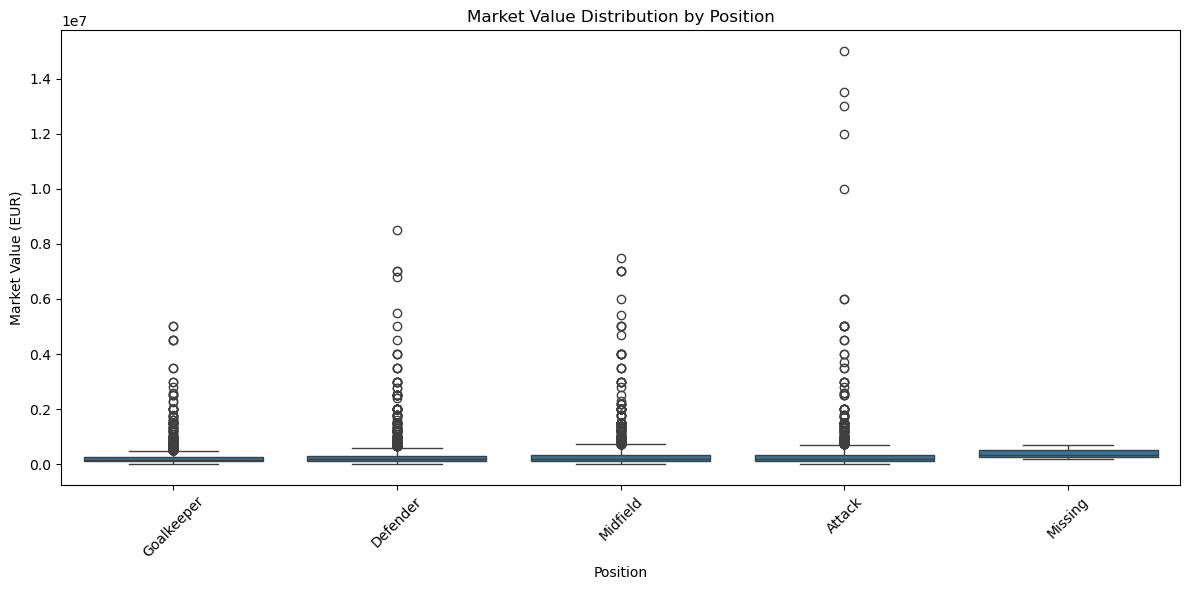

In [64]:
# Boxplot: Market Value by Position, colored by goal-scoring performance
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x='position', y='market_value_in_eur_valuation')
plt.xlabel('Position')
plt.ylabel('Market Value (EUR)')
plt.title('Market Value Distribution by Position')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Creating position-specific analysis for Goals...
Note: Filtering to players with >0 goals to show meaningful relationships


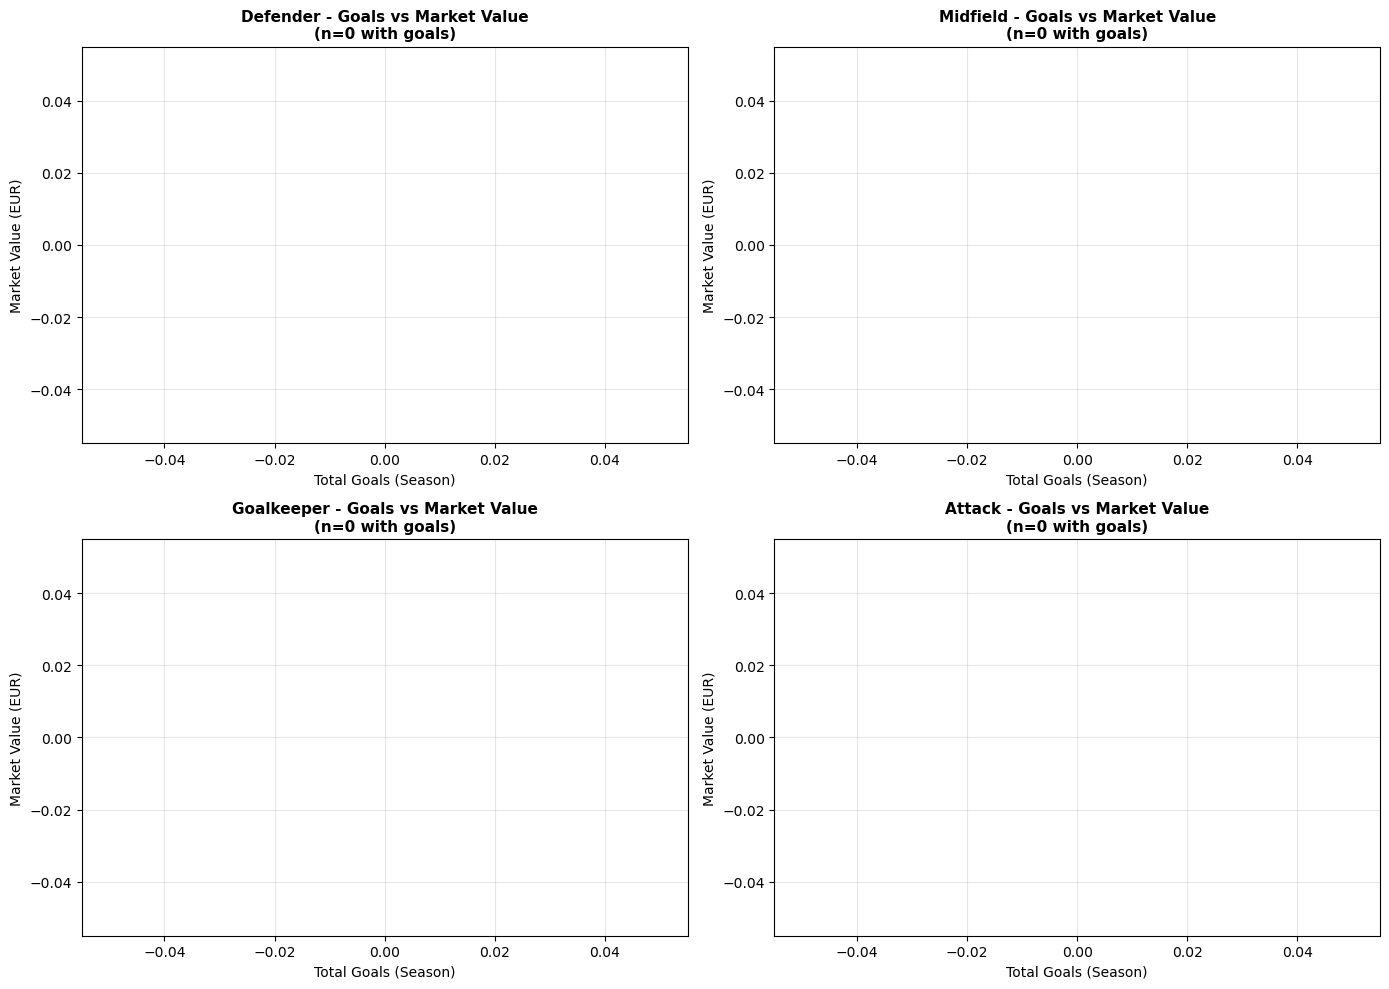


Data coverage after leakage fix:
  Defender: 0/2941 (0.0%) have goals before valuation
  Midfield: 0/2439 (0.0%) have goals before valuation
  Goalkeeper: 0/2197 (0.0%) have goals before valuation
  Attack: 0/1759 (0.0%) have goals before valuation


In [73]:
# ========== Faceted Analysis: Goals by Position (FILTERED FOR ACTIVE PLAYERS) ==========
print("Creating position-specific analysis for Goals...")
print("Note: Filtering to players with >0 goals to show meaningful relationships")

# Get unique positions
positions = merged_df['position'].value_counts().index[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    # FILTER: Only players with goals > 0
    pos_data = merged_df[(merged_df['position'] == pos) & (merged_df['total_goals'] > 0)].copy()
    
    axes[idx].scatter(pos_data['total_goals'], 
                      pos_data['market_value_in_eur_valuation'],
                      alpha=0.4, s=15, color='steelblue')
    axes[idx].set_xlabel('Total Goals (Season)', fontsize=10)
    axes[idx].set_ylabel('Market Value (EUR)', fontsize=10)
    axes[idx].set_title(f'{pos} - Goals vs Market Value\n(n={len(pos_data)} with goals)', 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line and calculate statistics
    if len(pos_data) > 10:
        try:
            # Calculate correlation
            correlation = pos_data[['total_goals', 'market_value_in_eur_valuation']].corr().iloc[0, 1]
            
            # Calculate slope (linear regression)
            z = np.polyfit(pos_data['total_goals'], pos_data['market_value_in_eur_valuation'], 1)
            slope = z[0]
            p = np.poly1d(z)
            
            # Plot trend line
            x_trend = np.linspace(pos_data['total_goals'].min(), pos_data['total_goals'].max(), 100)
            axes[idx].plot(x_trend, p(x_trend), "r--", alpha=0.6, linewidth=2)
            
            # Add text box with statistics
            textstr = f'Slope: €{slope:,.0f}/goal\nCorr: {correlation:.3f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            axes[idx].text(0.95, 0.95, textstr, transform=axes[idx].transAxes, 
                          fontsize=9, verticalalignment='top', horizontalalignment='right',
                          bbox=props)
        except Exception as e:
            print(f"Could not calculate stats for {pos}: {e}")

plt.tight_layout()
plt.show()

# Print summary
print("\nData coverage after leakage fix:")
for pos in positions:
    total = len(merged_df[merged_df['position'] == pos])
    with_goals = len(merged_df[(merged_df['position'] == pos) & (merged_df['total_goals'] > 0)])
    print(f"  {pos}: {with_goals}/{total} ({with_goals/total*100:.1f}%) have goals before valuation")

Creating position-specific analysis for Assists...
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/Users/Zevin/miniforge3/envs/gas/lib/python3.10/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

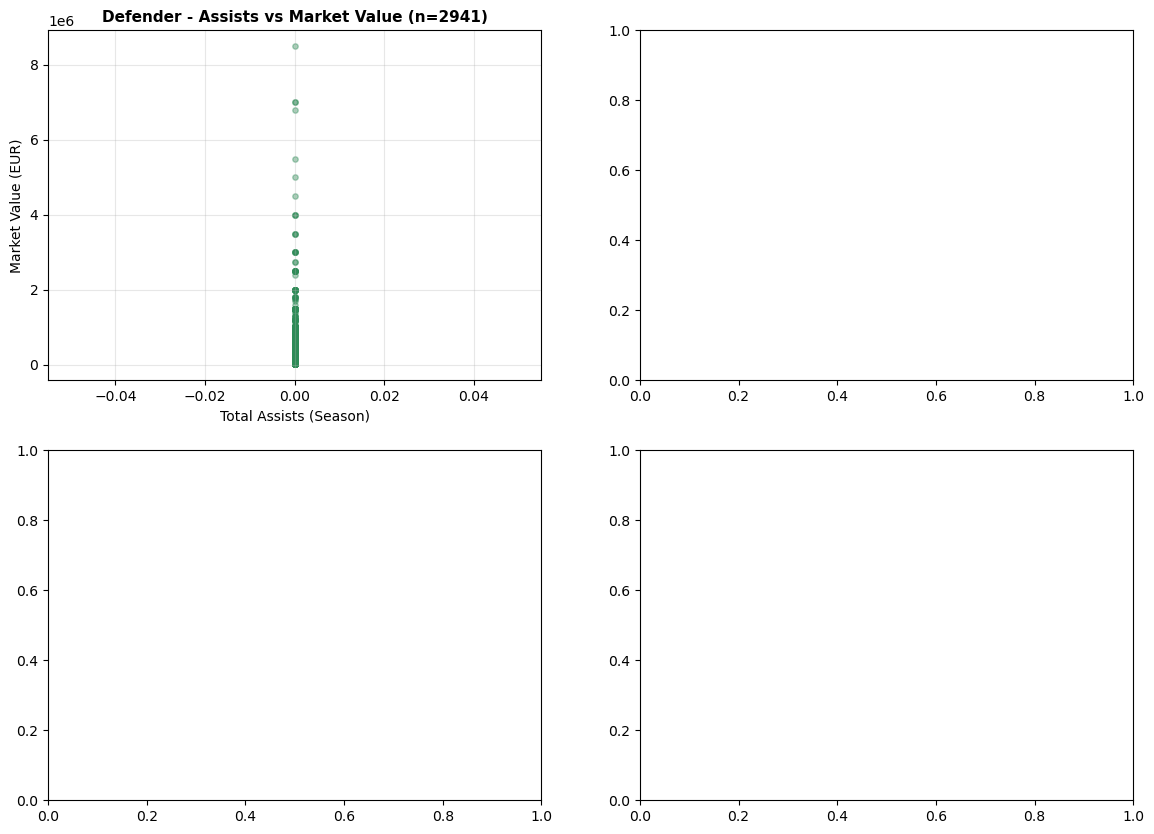

In [66]:
# Faceted Analysis: Assists by Position with Correlation Stats 
print("Creating position-specific analysis for Assists...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    pos_data = merged_df[merged_df['position'] == pos]
    
    axes[idx].scatter(pos_data['total_assists'], 
                      pos_data['market_value_in_eur_valuation'],
                      alpha=0.4, s=15, color='seagreen')
    axes[idx].set_xlabel('Total Assists (Season)', fontsize=10)
    axes[idx].set_ylabel('Market Value (EUR)', fontsize=10)
    axes[idx].set_title(f'{pos} - Assists vs Market Value (n={len(pos_data)})', 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line and calculate statistics
    if len(pos_data) > 10:
        # Calculate correlation
        correlation = pos_data[['total_assists', 'market_value_in_eur_valuation']].corr().iloc[0, 1]
        
        # Calculate slope (linear regression)
        z = np.polyfit(pos_data['total_assists'], pos_data['market_value_in_eur_valuation'], 1)
        slope = z[0]
        p = np.poly1d(z)
        
        # Plot trend line
        x_trend = np.linspace(pos_data['total_assists'].min(), pos_data['total_assists'].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), "r--", alpha=0.6, linewidth=2)
        
        # Add text box with statistics in top right
        textstr = f'Slope: €{slope:,.0f}/assist\nCorr: {correlation:.3f}'
        props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
        axes[idx].text(0.95, 0.95, textstr, transform=axes[idx].transAxes, 
                      fontsize=9, verticalalignment='top', horizontalalignment='right',
                      bbox=props)

plt.tight_layout()
plt.show()

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/Users/Zevin/miniforge3/envs/gas/lib/python3.10/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

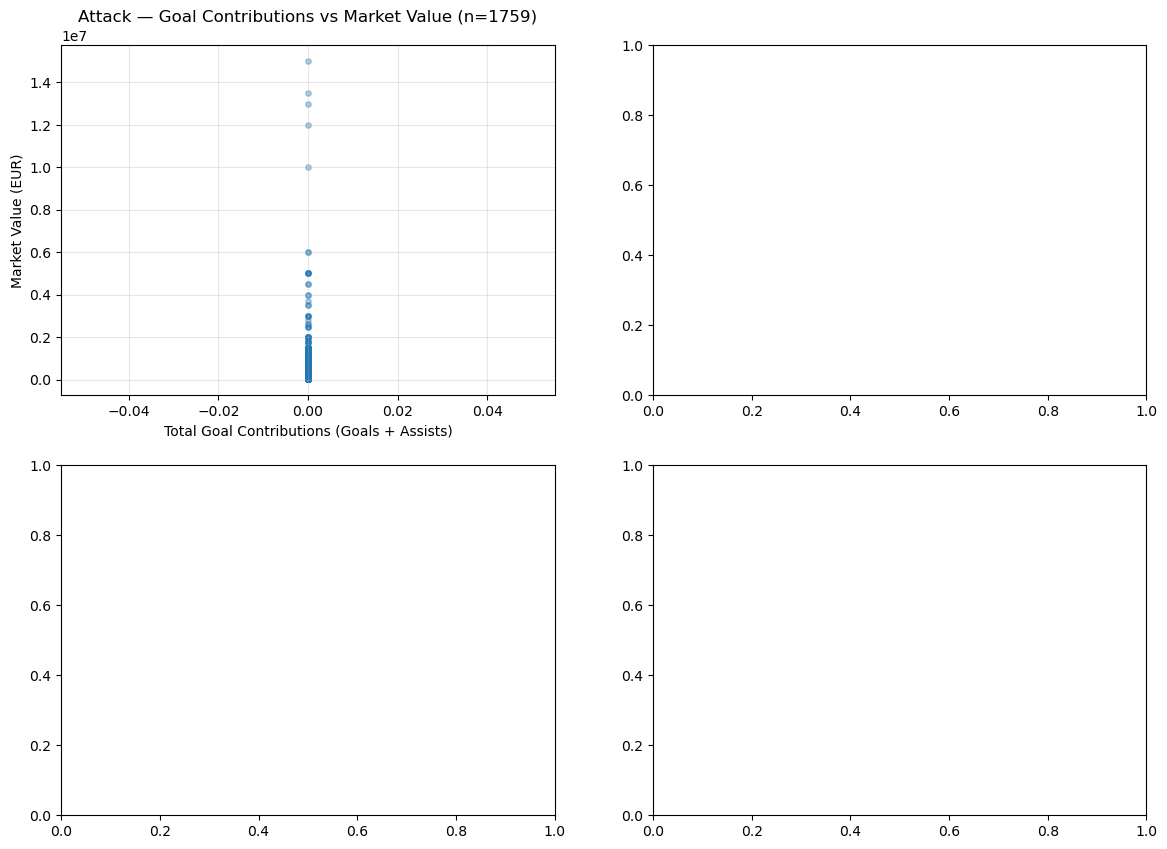

In [68]:
# Goal contributions = goals + assists (season totals)
merged_df["total_goal_contributions"] = merged_df["total_goals"] + merged_df["total_assists"]

# (optional) also look at per-90 since minutes are very uneven
# you already made goal_contributions_per_90 in perf_stats; this just ensures it exists in merged_df
# merged_df["goal_contributions_per_90"] should be present after merging perf_stats :contentReference[oaicite:3]{index=3}

positions = ["Attack", "Midfield", "Defender", "Goalkeeper"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    pos_data = merged_df[merged_df["position"] == pos].copy()

    # helpful: drop missing/inf just for plotting
    pos_data = pos_data.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["total_goal_contributions", "market_value_in_eur_valuation"]
    )

    axes[idx].scatter(
        pos_data["total_goal_contributions"],
        pos_data["market_value_in_eur_valuation"],
        alpha=0.35, s=15
    )
    axes[idx].set_xlabel("Total Goal Contributions (Goals + Assists)")
    axes[idx].set_ylabel("Market Value (EUR)")
    axes[idx].set_title(f"{pos} — Goal Contributions vs Market Value (n={len(pos_data)})")
    axes[idx].grid(True, alpha=0.3)

    if len(pos_data) > 10:
        corr = pos_data[["total_goal_contributions", "market_value_in_eur_valuation"]].corr().iloc[0, 1]
        z = np.polyfit(pos_data["total_goal_contributions"], pos_data["market_value_in_eur_valuation"], 1)
        slope = z[0]
        p = np.poly1d(z)

        x_trend = np.linspace(pos_data["total_goal_contributions"].min(),
                              pos_data["total_goal_contributions"].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), "r--", alpha=0.7, linewidth=2)

        axes[idx].text(
            0.95, 0.95,
            f"Slope: €{slope:,.0f}/(G+A)\nCorr: {corr:.3f}",
            transform=axes[idx].transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.8)
        )

plt.tight_layout()
plt.show()


count    9.344000e+03
mean     2.904934e+05
std      5.236895e+05
min      1.000000e+04
25%      1.000000e+05
50%      1.750000e+05
75%      3.000000e+05
max      1.500000e+07
Name: market_value_next_year, dtype: float64

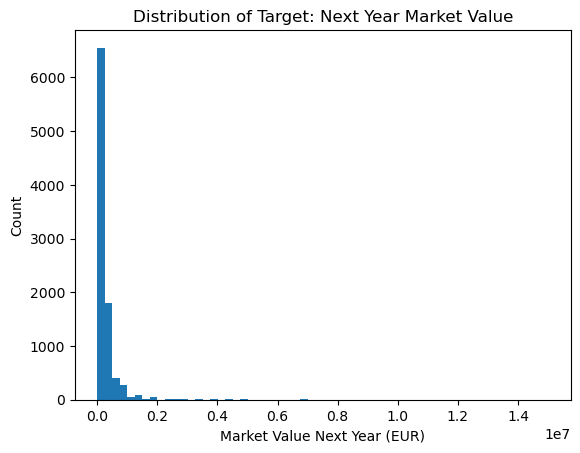

In [69]:
# Statistics

display(y.describe())

plt.figure()
plt.hist(y, bins=60)
plt.xlabel("Market Value Next Year (EUR)")
plt.ylabel("Count")
plt.title("Distribution of Target: Next Year Market Value")
plt.show()


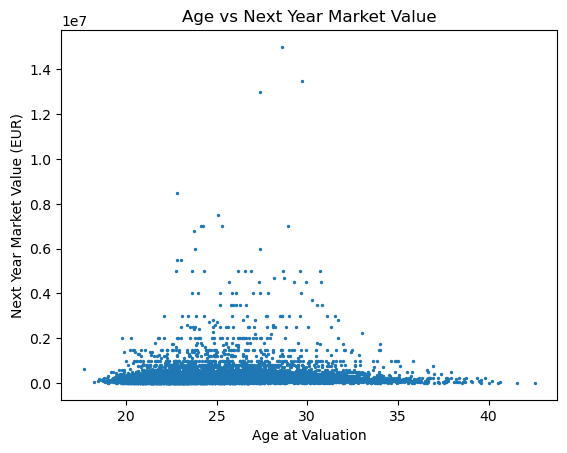

In [70]:
# age vs next-year value

plt.figure()
plt.scatter(merged_df["age_at_valuation"], merged_df["market_value_next_year"], s=2)
plt.xlabel("Age at Valuation")
plt.ylabel("Next Year Market Value (EUR)")
plt.title("Age vs Next Year Market Value")
plt.show()


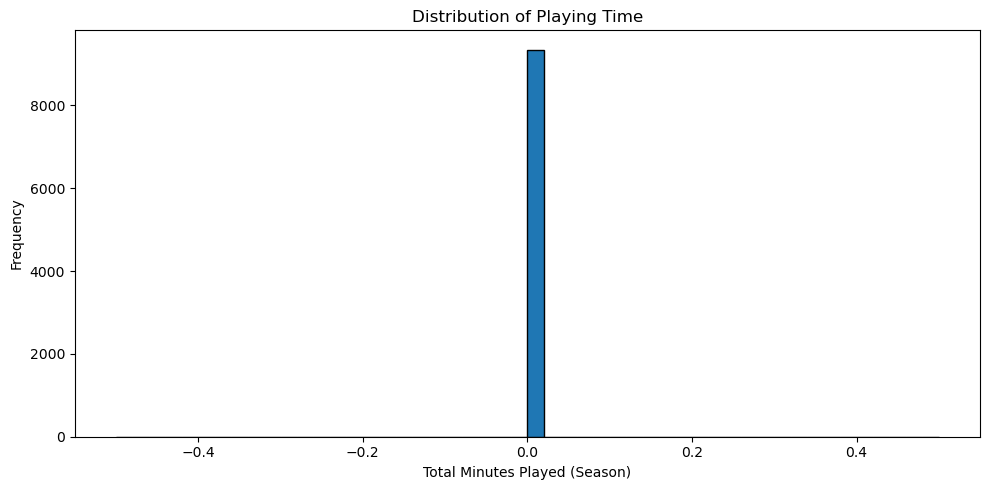

In [71]:
# Minutes Played Distribution
plt.figure(figsize=(10, 5))
plt.hist(merged_df['total_minutes'], bins=50, edgecolor='black')
plt.xlabel('Total Minutes Played (Season)')
plt.ylabel('Frequency')
plt.title('Distribution of Playing Time')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

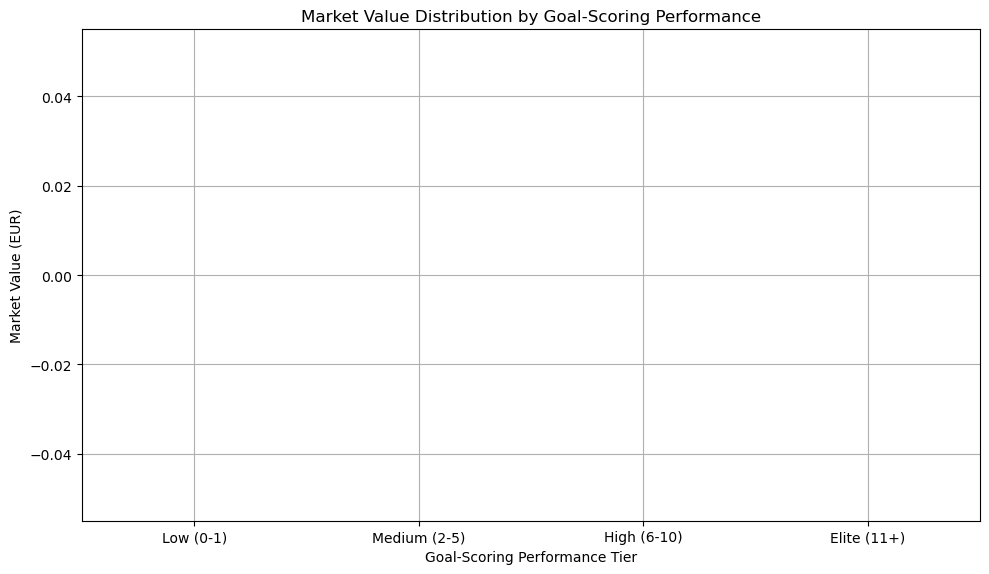

In [72]:
# Market Value by Performance Tier (boxplot)
# Create performance tiers
merged_df['performance_tier'] = pd.cut(
    merged_df['total_goals'], 
    bins=[0, 1, 5, 10, 100], 
    labels=['Low (0-1)', 'Medium (2-5)', 'High (6-10)', 'Elite (11+)']
)

plt.figure(figsize=(10, 6))
merged_df.boxplot(column='market_value_in_eur_valuation', by='performance_tier', 
                  figsize=(10, 6))
plt.xlabel('Goal-Scoring Performance Tier')
plt.ylabel('Market Value (EUR)')
plt.title('Market Value Distribution by Goal-Scoring Performance')
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

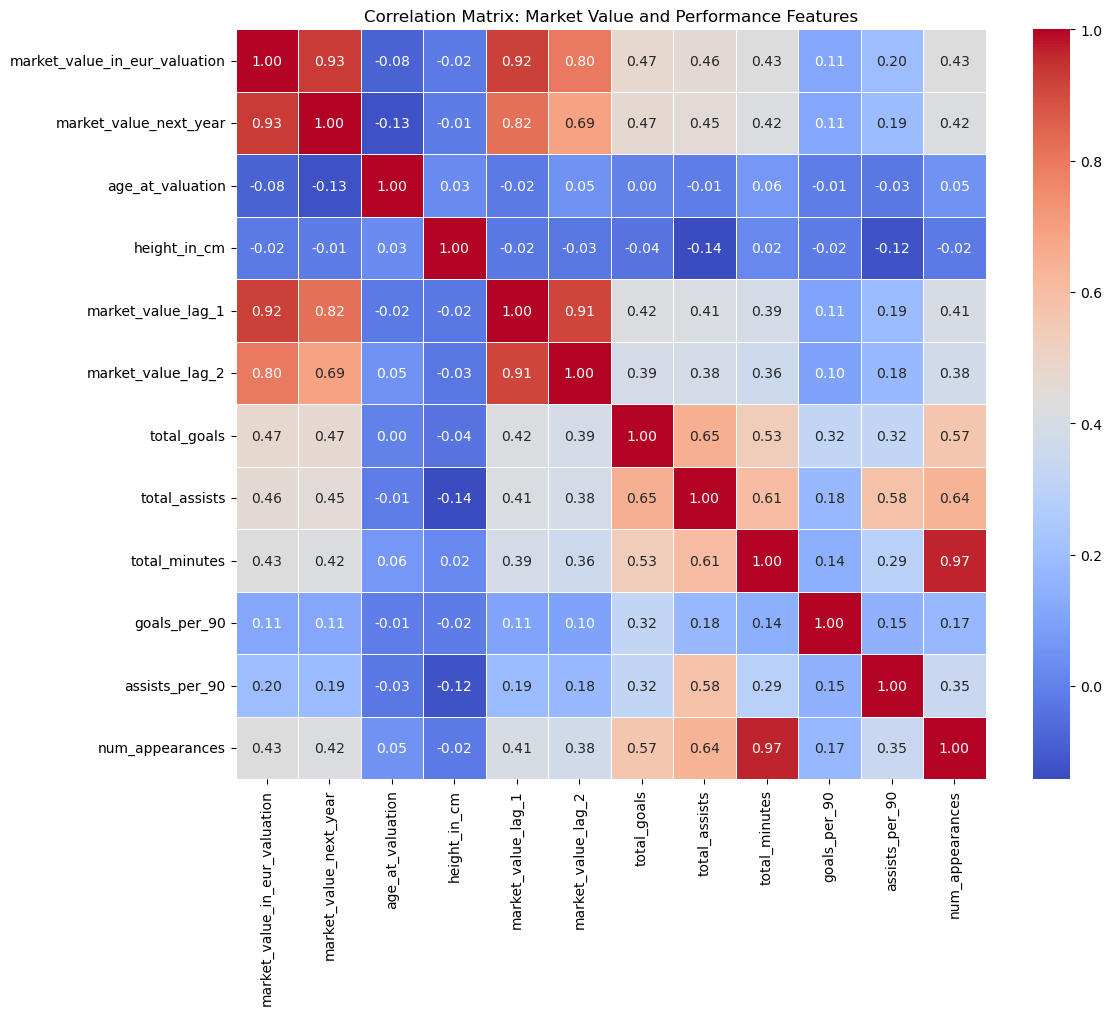

In [ ]:
# Correlation heatmap 
import seaborn as sns

# Select key features including performance stats
corr_features = ['market_value_in_eur_valuation', 'market_value_next_year',
                 'age_at_valuation', 'height_in_cm',
                 'market_value_lag_1', 'market_value_lag_2',
                 'total_goals', 'total_assists', 'total_minutes',
                 'goals_per_90', 'assists_per_90', 'num_appearances']

corr_matrix = merged_df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Market Value and Performance Features')
plt.tight_layout()
plt.show()


## 4. Data Analytics (Modeling)
This is a **supervised learning regression** problem. We compare multiple algorithms and evaluate them using MAE, RMSE, and R². We also do time-aware train/test splitting to reduce leakage risk.

In [ ]:
# Train/Test split (time-aware)
# We preserve order (shuffle=False) because data is time-dependent.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (110807, 61) (110807,)
Test: (27702, 61) (27702,)


We compare:
- Linear Regression (baseline)
- ElasticNet (regularized linear)
- Random Forest (non-linear)
- KNN (distance-based)

For KNN and ElasticNet we benefit from scaling, so we use pipelines.

In [ ]:
# Models + evaluation

# def evaluate_model(name,model, X_tr, y_tr, X_te, y_te):
#     model.fit(X_tr, y_tr
#     )
#     pred = model.predict(X_te)
#     return {
#         "Model": name,
#         "MAE": mean_absolute_error(y_te, pred),
#         "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
#         "R2": r2_score(y_te, pred)
#     }


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train model, evaluate on test set, and perform cross-validation
    """
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Test set predictions
    pred = model.predict(X_te)
    
    # Cross-validation on training set (5-fold)
    print(f"\n{'='*60}")
    print(f"Cross-Validation: {name}")
    print(f"{'='*60}")
    
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    cv_mae = -cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
    
    print(f"  R² scores:   {cv_r2}")
    print(f"  Mean R²:     {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
    print(f"  MAE scores:  {cv_mae}")
    print(f"  Mean MAE:    €{cv_mae.mean():,.2f} (+/- €{cv_mae.std():,.2f})")
    print(f"  RMSE scores: {cv_rmse}")
    print(f"  Mean RMSE:   €{cv_rmse.mean():,.2f} (+/- €{cv_rmse.std():,.2f})")
    
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2": r2_score(y_te, pred),
        "CV_R2_Mean": cv_r2.mean(),
        "CV_R2_Std": cv_r2.std(),
        "CV_MAE_Mean": cv_mae.mean(),
        "CV_RMSE_Mean": cv_rmse.mean()
    }

models = []

# Baselines (no scaling needed)
models.append(("Linear Regression", LinearRegression()))
models.append(("Random Forest", RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)))

# Pipelines (imputer + scaler) helps for KNN/ElasticNet
elastic_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
])

knn_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

models.append(("ElasticNet (scaled)", elastic_pipe))
models.append(("KNN (scaled)", knn_pipe))

results = []
for name, model in models:
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df



Cross-Validation: Linear Regression
  R² scores:   [0.76639275 0.72291478 0.72895524 0.71541241 0.68647461]
  Mean R²:     0.7240 (+/- 0.0257)
  MAE scores:  [1631283.72579812 1448861.90106528 1384132.04682679 1450143.86652132
 1648106.84275165]
  Mean MAE:    €1,512,505.68 (+/- €106,691.35)
  RMSE scores: [3151954.47586866 3036196.91986206 3364500.16000056 3861704.72343815
 4152941.58006453]
  Mean RMSE:   €3,513,459.57 (+/- €426,817.62)

Cross-Validation: Random Forest
  R² scores:   [0.78299724 0.79868    0.8117112  0.7937659  0.73917071]
  Mean R²:     0.7853 (+/- 0.0248)
  MAE scores:  [1132375.88946279 1002358.33543844  934376.17163398 1071524.06076857
 1275181.7478238 ]
  Mean MAE:    €1,083,163.24 (+/- €116,700.89)
  RMSE scores: [3037871.53862231 2588014.53896099 2804221.37633236 3287390.70935332
 3787892.48865158]
  Mean RMSE:   €3,101,078.13 (+/- €415,157.70)

Cross-Validation: ElasticNet (scaled)
  R² scores:   [0.75784206 0.72192093 0.72574775 0.71147531 0.68419422]
  Mea

,Model,MAE,RMSE,R2,CV_R2_Mean,CV_R2_Std,CV_MAE_Mean,CV_RMSE_Mean
1,Random Forest,1.738692e+06,5.107255e+06,0.763978,0.785265,0.024825,1.083163e+06,3.101078e+06
2,ElasticNet (scaled),2.109499e+06,5.464142e+06,0.729840,0.720236,0.023762,1.501577e+06,3.538290e+06
0,Linear Regression,2.115212e+06,5.402000e+06,0.735950,0.724030,0.025709,1.512506e+06,3.513460e+06
3,KNN (scaled),2.192473e+06,6.289459e+06,0.642065,0.644725,0.034766,1.489854e+06,3.974262e+06


We use `TimeSeriesSplit` to evaluate models with time-aware cross-validation. This avoids mixing future information into training folds.

In [ ]:
# TimeSeries cross-validation (on a subset for speed)

tscv = TimeSeriesSplit(n_splits=5)

# For speed, sample a subset
sample_size = min(120000, len(X_train))
X_cv = X_train.iloc[:sample_size]
y_cv = y_train.iloc[:sample_size]

# Use MAE (negative in sklearn scoring conventions)
def cv_mae(model):
    scores = cross_val_score(
        model, X_cv, y_cv,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -scores.mean(), scores.std()

cv_rows = []
for name, model in models:
    mean_mae, std_mae = cv_mae(model)
    cv_rows.append({"Model": name, "CV_MAE_mean": mean_mae, "CV_MAE_std": std_mae})

cv_df = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
cv_df

,Model,CV_MAE_mean,CV_MAE_std
1,Random Forest,1.101874e+06,128558.983165
2,ElasticNet (scaled),1.433346e+06,131374.678765
0,Linear Regression,1.438916e+06,136579.177682
3,KNN (scaled),1.545261e+06,155333.787683


We inspect which features contribute most to predictions (interpretability).

market_value_lag_1           0.662780
age_at_valuation             0.086828
starts                       0.018272
games_started_estimate       0.017700
total_goals                  0.015810
goal_contributions_per_90    0.015574
total_minutes                0.015499
current_club_id_valuation    0.014080
num_appearances              0.012899
minutes_trend                0.011082
minutes_lag_1                0.010490
height_in_cm                 0.009298
market_value_trend           0.009125
lineup_matches               0.008546
market_value_mean_3          0.008215
dtype: float64

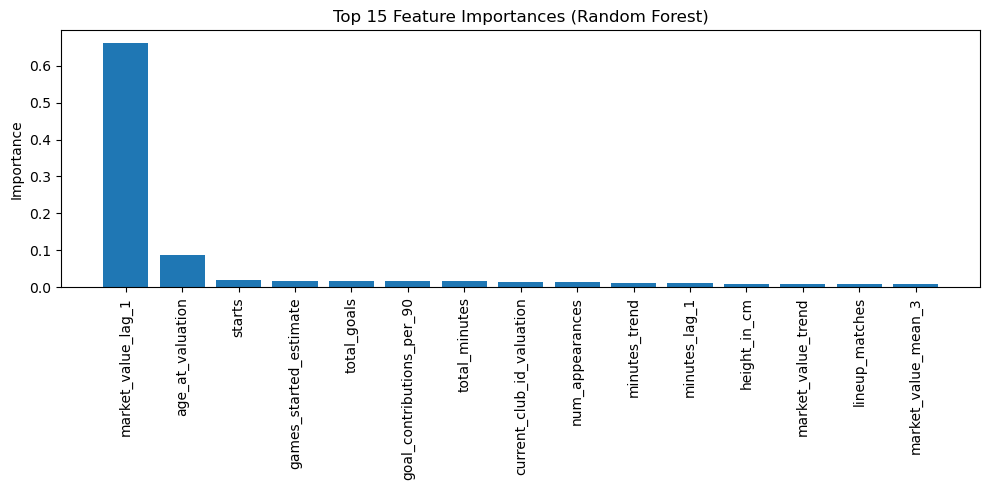

In [ ]:
# Feature importance (Random Forest)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Compute importances
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_k = 15
display(importances.head(top_k))

# Plot feature importances
top_feats = importances.head(top_k)

x = np.arange(len(top_feats))
y = top_feats.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xticks(x, top_feats.index, rotation=90)
plt.ylabel("Importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [ ]:
# Analyze top performing features - NEW
print("=" * 60)
print("Top 20 Feature Importances (Random Forest)")
print("=" * 60)

# Get feature importances from your trained RF model
rf = RandomForestRegressor(n_estimators=150, max_depth=18, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\nTop 20 Features:")
display(importances.head(20))

# Highlight performance features
print("\n⚽ Performance-Related Features in Top 20:")
perf_feature_keywords = ['goal', 'assist', 'minutes', 'appearance', 'cards']
top_20_features = importances.head(20)
for feat in top_20_features.index:
    if any(keyword in feat.lower() for keyword in perf_feature_keywords):
        print(f"  - {feat}: {top_20_features[feat]:.4f}")

Top 20 Feature Importances (Random Forest)

Top 20 Features:


market_value_lag_1           0.662780
age_at_valuation             0.086828
starts                       0.018272
games_started_estimate       0.017700
total_goals                  0.015810
goal_contributions_per_90    0.015574
total_minutes                0.015499
current_club_id_valuation    0.014080
num_appearances              0.012899
minutes_trend                0.011082
minutes_lag_1                0.010490
height_in_cm                 0.009298
market_value_trend           0.009125
lineup_matches               0.008546
market_value_mean_3          0.008215
start_ratio                  0.007760
total_assists                0.007524
goals_per_90                 0.007314
cards_per_90                 0.006428
assists_per_90               0.005725
dtype: float64


⚽ Performance-Related Features in Top 20:
  - total_goals: 0.0158
  - goal_contributions_per_90: 0.0156
  - total_minutes: 0.0155
  - num_appearances: 0.0129
  - minutes_trend: 0.0111
  - minutes_lag_1: 0.0105
  - total_assists: 0.0075
  - goals_per_90: 0.0073
  - cards_per_90: 0.0064
  - assists_per_90: 0.0057


A quick diagnostic plot to visually assess model fit.

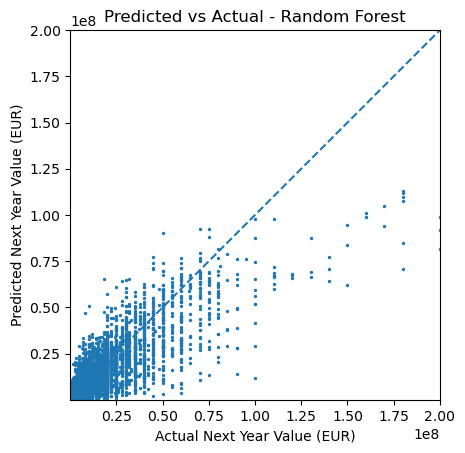

In [ ]:
# Predicted vs actual

best_model_name = results_df.iloc[0]["Model"]
best_model = dict(models)[best_model_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.figure()
plt.scatter(y_test, pred, s=2)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.gca().set_aspect("equal", adjustable="box")

plt.plot([min_val,max_val],[min_val,max_val],linestyle='--')

plt.xlabel("Actual Next Year Value (EUR)")
plt.ylabel("Predicted Next Year Value (EUR)")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.show()


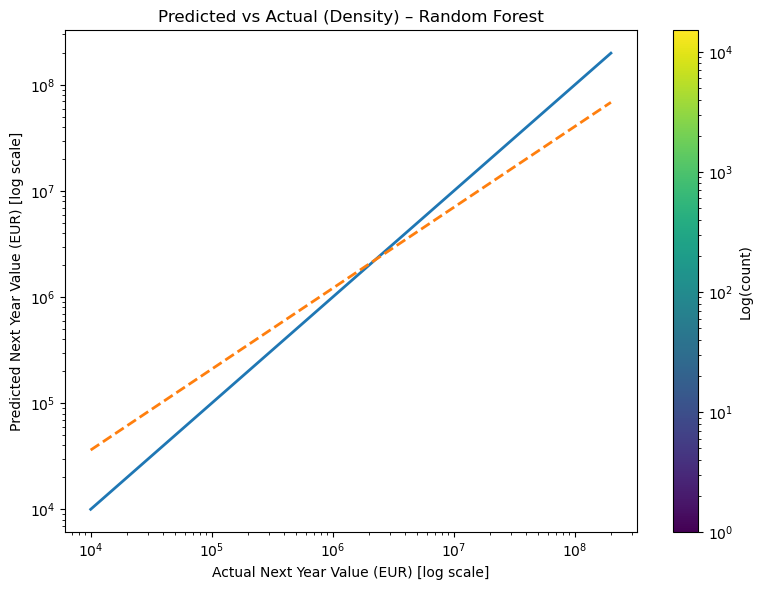

In [ ]:

# Predicted vs Actual 

final_model_name = results_df.iloc[0]["Model"]
final_model = dict(models)[final_model_name]

final_model.fit(X_train, y_train)
pred = final_model.predict(X_test)

# Convert to numpy arrays and remove non-positive values for log scaling
y_true = np.asarray(y_test).astype(float)
y_pred = np.asarray(pred).astype(float)

mask = (y_true > 0) & (y_pred > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# 1) HEXBIN DENSITY PLOT (final when there are many points)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true, y_pred, gridsize=60, bins='log')  # density in log bins
plt.colorbar(hb, label="Log(count)")

# Log scales (makes long-tail readable)
plt.xscale("log")
plt.yscale("log")

# 45-degree line (perfect predictions)
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linewidth=2)

# Fit line to log10 values to show overall calibration
logx = np.log10(y_true)
logy = np.log10(y_pred)
m, b = np.polyfit(logx, logy, 1)
x_line = np.logspace(np.log10(min_v), np.log10(max_v), 200)
y_line = 10**(m*np.log10(x_line) + b)
plt.plot(x_line, y_line, linestyle="--", linewidth=2)

plt.xlabel("Actual Next Year Value (EUR) [log scale]")
plt.ylabel("Predicted Next Year Value (EUR) [log scale]")
plt.title(f"Predicted vs Actual (Density) – {final_model_name}")
plt.tight_layout()
plt.show()


## 5. Summary / Conclusions

- We framed the task as **supervised regression** to predict next-year market value.  
- We used **time-aware feature engineering** (lags, trends, rolling means) and a **time-aware train/test split** to reduce leakage risk.  
- We compared multiple models and evaluated them with **MAE, RMSE, and R²**, then validated via **TimeSeriesSplit** cross-validation.   
